In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [2]:
df = pd.read_csv("Salary Data.csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
print(df.shape)

(375, 6)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
None


In [5]:
print(df.describe())

              Age  Years of Experience         Salary
count  373.000000           373.000000     373.000000
mean    37.431635            10.030831  100577.345845
std      7.069073             6.557007   48240.013482
min     23.000000             0.000000     350.000000
25%     31.000000             4.000000   55000.000000
50%     36.000000             9.000000   95000.000000
75%     44.000000            15.000000  140000.000000
max     53.000000            25.000000  250000.000000


# Check Missing Values

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

# Remove Missing Values

In [7]:
df.dropna(inplace=True)

df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

# Check Duplicate Records

In [8]:
print(df.duplicated().sum())

49


# Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

print(df.shape)

(324, 6)


# Encode Categorical Columns

In [10]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df["Education Level"] = le.fit_transform(df["Education Level"])

df["Job Title"] = le.fit_transform(df["Job Title"])

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


# Salary Distribution

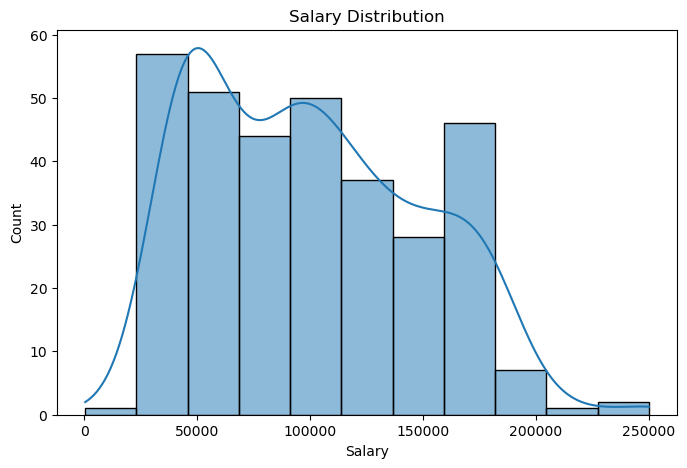

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], kde=True)

plt.title("Salary Distribution")

plt.show()

# Correlation Heatmap

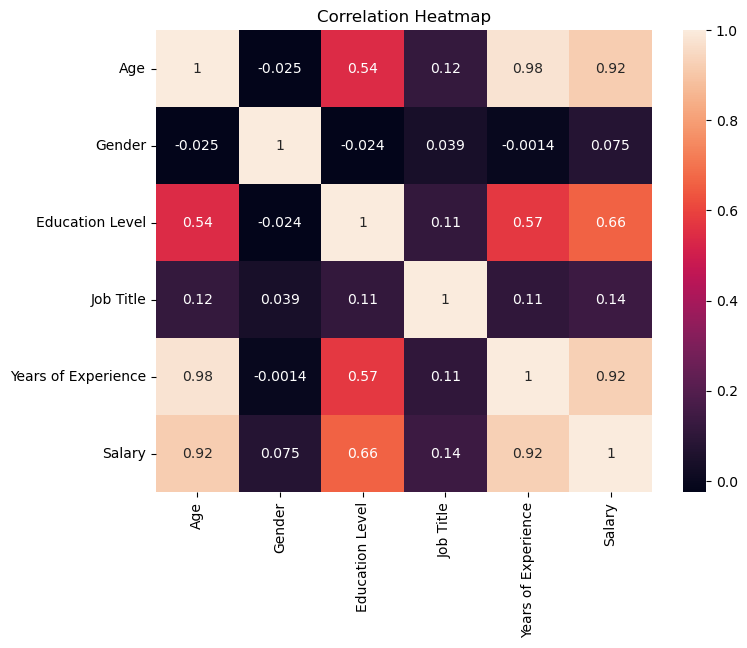

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Experience VS Salary

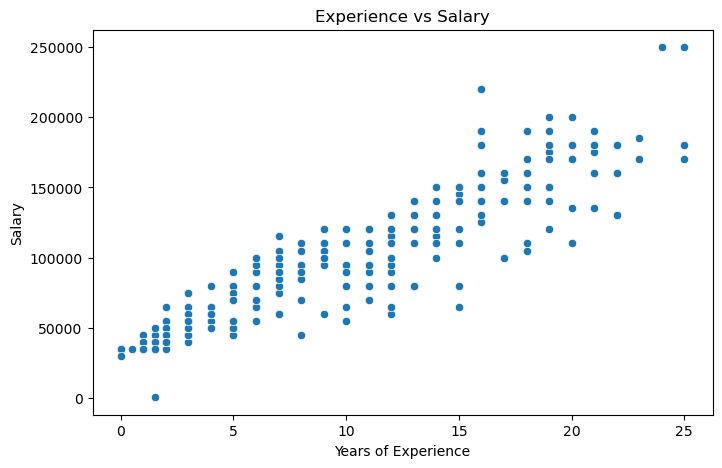

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Years of Experience",
    y="Salary",
    data=df
)

plt.title("Experience vs Salary")

plt.show()

# Age vs Salary

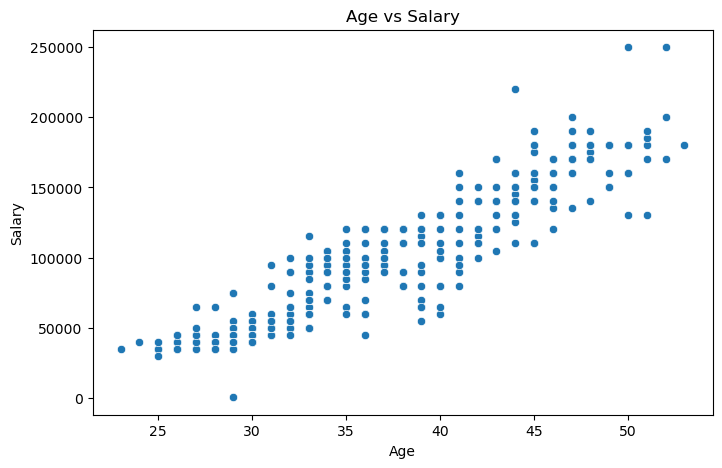

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Salary",
    data=df
)

plt.title("Age vs Salary")

plt.show()

# Feature Selection

In [17]:
X = df.drop("Salary", axis=1)

y = df["Salary"]

# Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Train Model

In [19]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction

In [21]:
y_pred = model.predict(X_test)

# Evaluate Model

In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 9317.23076923077
MSE : 160898749.14380342
RMSE : 12684.587070291387
R2 Score : 0.9148587906175745


# Feature Importance Graph

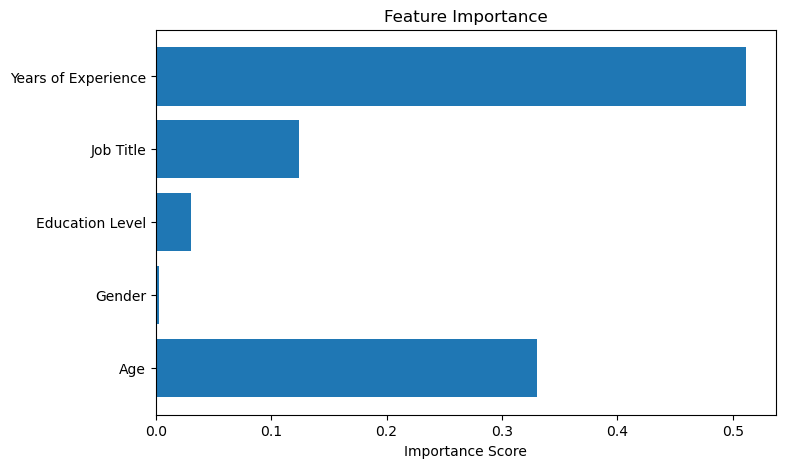

In [23]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

# Actual vs Predicted Salary

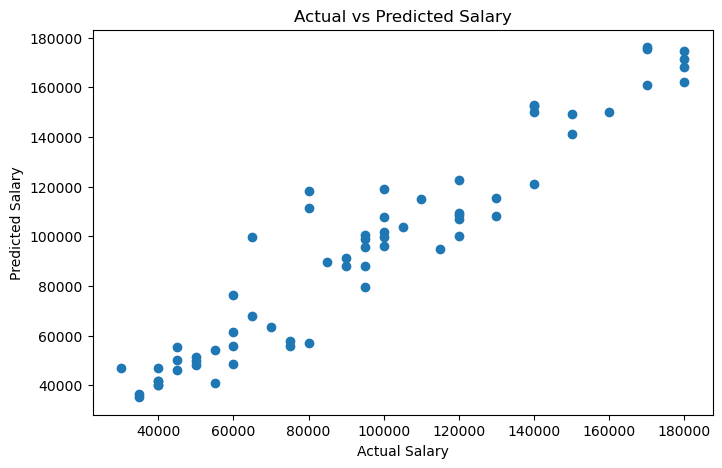

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

# Conclusion

In [26]:
print("""
Conclusion:

1. Salary Prediction model was successfully developed.
2. Random Forest Regressor was used.
3. The model predicts employee salaries using:
   - Age
   - Gender
   - Education Level
   - Job Title
   - Years of Experience
4. R2 Score indicates the model performance.
5. Years of Experience and Job Title are important factors affecting salary.
""")


Conclusion:

1. Salary Prediction model was successfully developed.
2. Random Forest Regressor was used.
3. The model predicts employee salaries using:
   - Age
   - Gender
   - Education Level
   - Job Title
   - Years of Experience
4. R2 Score indicates the model performance.
5. Years of Experience and Job Title are important factors affecting salary.

